In [1]:
import pandas as pd 
import numpy as np

In [2]:
FILE_PATH = '../data/raw/bank-additional-full.csv'

df = pd.read_csv(FILE_PATH, sep=';')
print(df.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [3]:
print(df.shape)
print(df.columns)

(41188, 21)
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Valores ausentes e categorias `unknown`

A base não tem `NaN` (confirmado pelo `df.info()`), mas várias colunas categóricas usam `"unknown"` como marcador de dado faltante.

In [6]:
print("Nulos por coluna:")
print(df.isnull().sum().sum(), "valores nulos no total\n")

cat_cols = df.select_dtypes(include='object').columns.drop('y')
unknown_counts = (df[cat_cols] == 'unknown').sum().sort_values(ascending=False)
unknown_pct = (unknown_counts / len(df) * 100).round(2)

pd.DataFrame({'qtd_unknown': unknown_counts, 'pct_unknown': unknown_pct})

Nulos por coluna:
0 valores nulos no total



,qtd_unknown,pct_unknown
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19
contact,0,0.00
month,0,0.00
day_of_week,0,0.00
poutcome,0,0.00


**Leitura:** `default` tem a maior proporção de `unknown` (~20%), seguido de `education` e `housing`/`loan`. Como o volume não é desprezível, a decisão adotada é **manter `unknown` como categoria própria** (em vez de imputar ou remover linhas).
ela pode carregar sinal real (ex.: cliente que não informa `default` pode ter perfil de risco diferente).

## Duplicatas

In [7]:
n_dup = df.duplicated().sum()
print(f"Linhas duplicadas: {n_dup} ({n_dup / len(df):.2%})")

Linhas duplicadas: 12 (0.03%)


## Taxa de conversão global (variável alvo `y`)

Essa é a métrica-base que o baseline e o bandit (Etapa 3) vão precisar superar.

y
no     36548
yes     4640
Name: count, dtype: int64

y
no     88.73%
yes    11.27%
Name: proportion, dtype: object


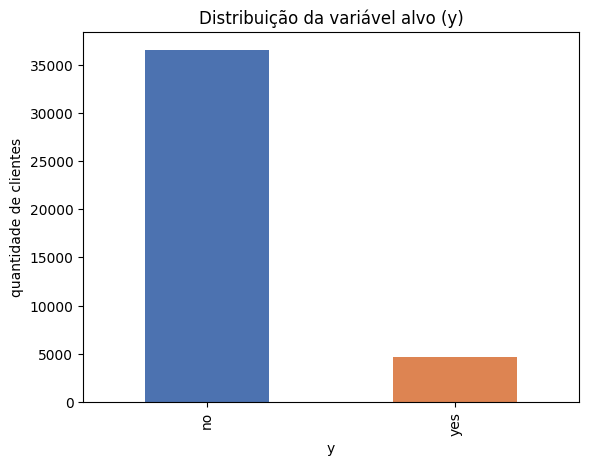

In [8]:
import matplotlib.pyplot as plt

conv_counts = df['y'].value_counts()
conv_rate = df['y'].value_counts(normalize=True)

print(conv_counts)
print()
print((conv_rate * 100).round(2).astype(str) + '%')

ax = conv_counts.plot(kind='bar', color=['#4C72B0', '#DD8452'], title='Distribuição da variável alvo (y)')
ax.set_xlabel('y')
ax.set_ylabel('quantidade de clientes')
plt.show()

**Leitura:** dataset fortemente desbalanceado, cerca de 11,3% de conversão (`yes`) contra 88,7% de não conversão (`no`). Isso é relevante para a Etapa 3: qualquer baseline que sempre recomende "não oferecer"/"produto padrão" já acerta ~89% se a métrica for acurácia bruta, por isso a métrica de comparação entre baseline e bandit deve ser **taxa de conversão obtida** (ou regret), não acurácia.

## Distribuição das variáveis numéricas

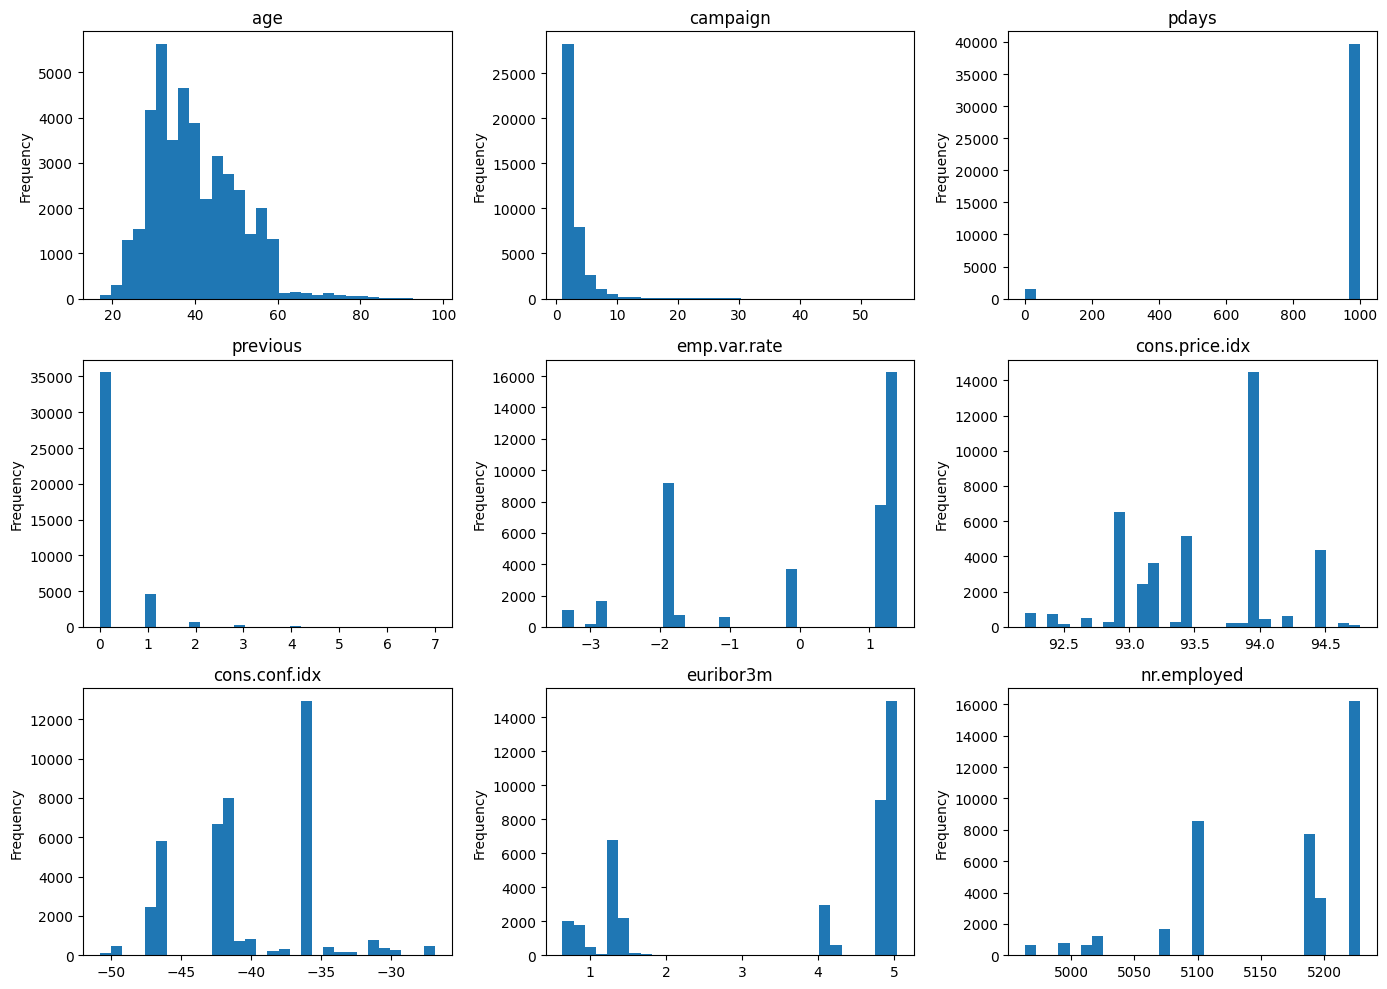

In [9]:
import matplotlib.pyplot as plt

num_cols = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
            'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for col, ax in zip(num_cols, axes.flatten()):
    df[col].plot(kind='hist', bins=30, ax=ax, title=col)
plt.tight_layout()
plt.show()

**Leitura:**
- `age` concentrada entre 30 e 50 anos, com cauda longa até 98.
- `campaign` (nº de contatos na campanha atual) é bem assimétrica. A maioria dos clientes recebe 1 a 3 contatos, poucos recebem muitos.
- `pdays` tem uma massa enorme em 999 (ver seção específica abaixo), isso distorce qualquer estatística direta sobre a coluna.
- As variáveis macroeconômicas (`emp.var.rate`, `euribor3m`, `nr.employed`) têm poucos valores distintos porque mudam por período da campanha, não por cliente. Funcionam mais como "contexto temporal" do que como atributo individual.

## `pdays` tem um valor especial (999)

Segundo o dicionário da base, `pdays = 999` significa "cliente nunca foi contatado antes". Isso não é um valor numérico comum — precisa ser tratado como categoria/flag, não como distância contínua.

% de clientes com pdays == 999 (nunca contatados antes): 96.32%


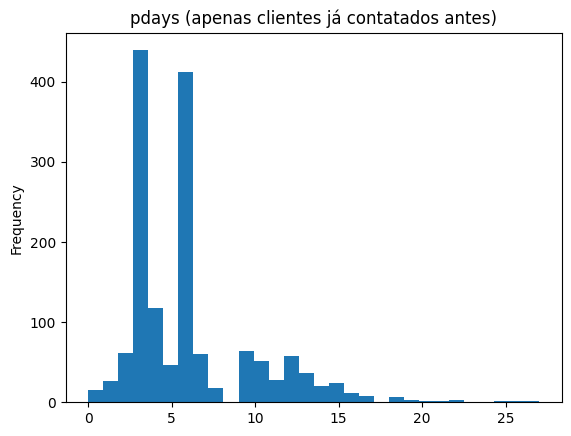

In [10]:
pct_999 = (df['pdays'] == 999).mean()
print(f"% de clientes com pdays == 999 (nunca contatados antes): {pct_999:.2%}")

df.loc[df['pdays'] != 999, 'pdays'].plot(
    kind='hist', bins=30, title='pdays (apenas clientes já contatados antes)'
)
plt.show()

**Leitura:** ~96% dos clientes nunca foram contatados em campanha anterior. Posteriormente isso vai derivar uma flag binária `foi_contatado_antes = (pdays != 999)` em vez de usar `pdays` como número contínuo diretamente.

## Distribuição das variáveis categóricas

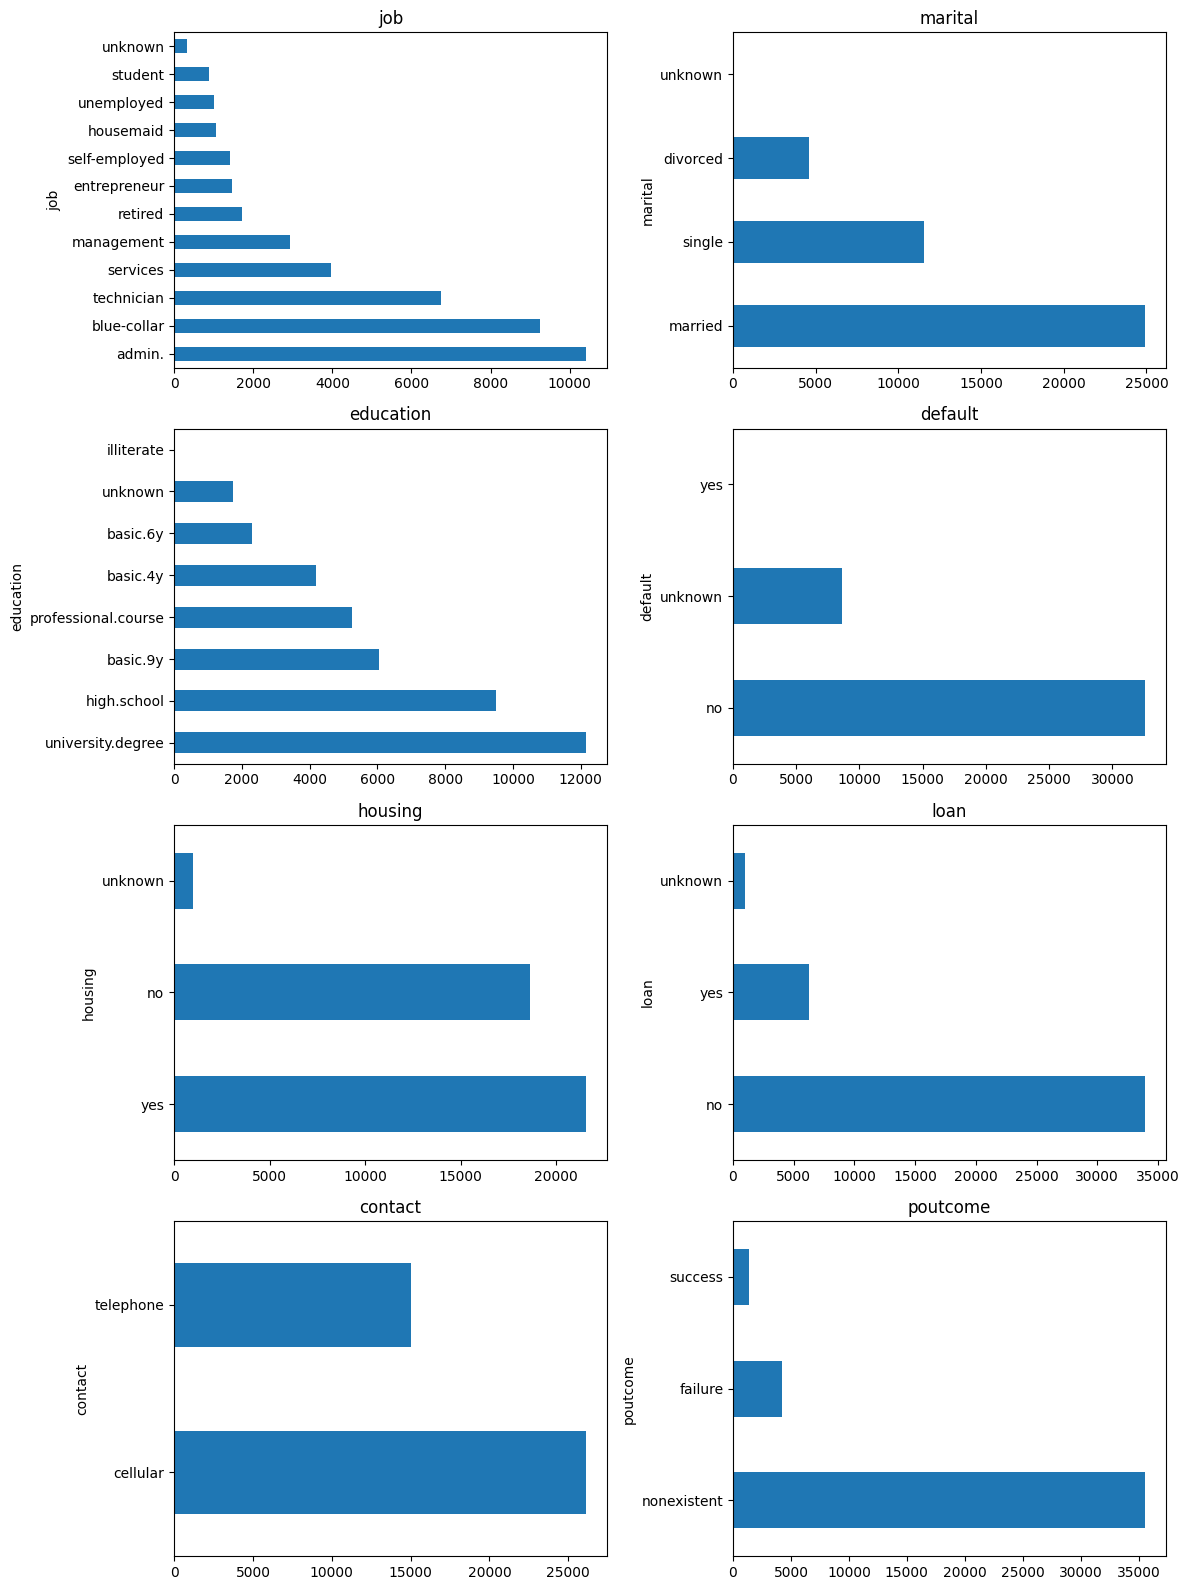

In [11]:
cat_cols_plot = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                 'contact', 'poutcome']

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
for col, ax in zip(cat_cols_plot, axes.flatten()):
    df[col].value_counts().plot(kind='barh', ax=ax, title=col)
plt.tight_layout()
plt.show()

## Taxa de conversão por categoria

Mais importante do que a distribuição isolada de cada categoria é como a **taxa de conversão** varia entre elas, é esse sinal que vai justificar os braços/segmentos do bandit na Etapa 2.

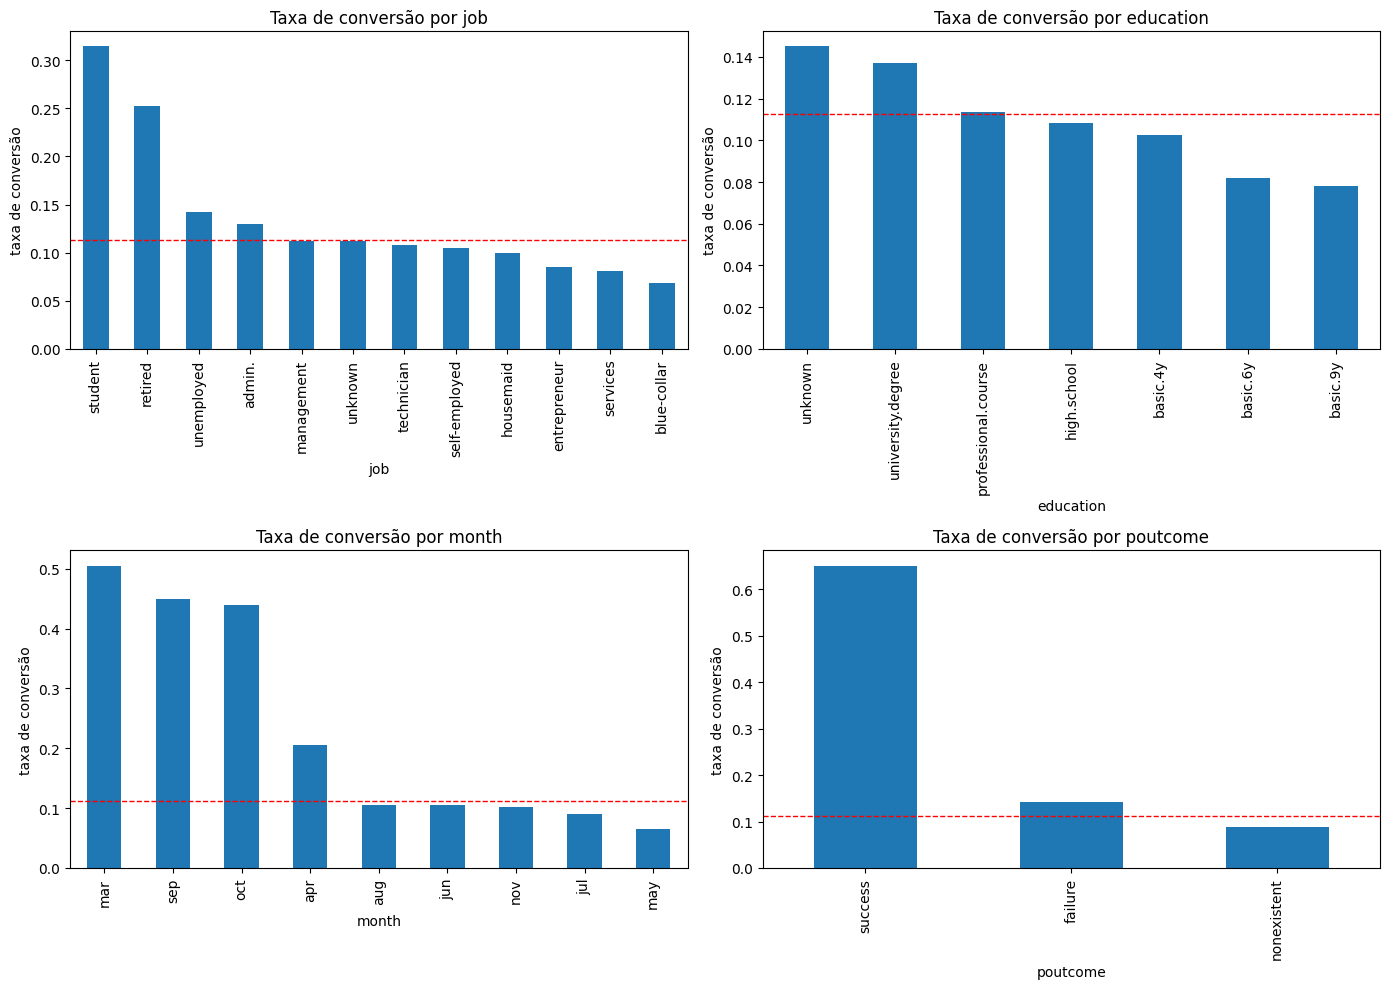

In [12]:
def taxa_conversao_por(col, min_n=200):
    tmp = df.groupby(col)['y'].apply(lambda s: (s == 'yes').mean())
    n = df[col].value_counts()
    tmp = tmp[n[tmp.index] >= min_n]  # ignora categorias com poucas observações
    return tmp.sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for col, ax in zip(['job', 'education', 'month', 'poutcome'], axes.flatten()):
    taxa = taxa_conversao_por(col)
    taxa.plot(kind='bar', ax=ax, title=f'Taxa de conversão por {col}')
    ax.axhline(conv_rate['yes'], color='red', linestyle='--', linewidth=1)
    ax.set_ylabel('taxa de conversão')
plt.tight_layout()
plt.show()

**Leitura:** existe variação real de conversão entre categorias (a linha vermelha é a média global de ~11,3%):
- `poutcome = success` (cliente já converteu em campanha anterior) tem taxa de conversão muito acima da média: sinal forte.
- `job`: `student` e `retired` convertem mais que `blue-collar` e `services`.
- `month`: meses como `mar`, `dec`, `sep`, `oct` têm taxa de conversão bem mais alta que os meses de maior volume (`may`, `jul`, `aug`).

Esses recortes (perfil do cliente + contexto da campanha) são candidatos naturais para condicionar o contexto do bandit na Etapa 3.

## Correlação entre variáveis numéricas

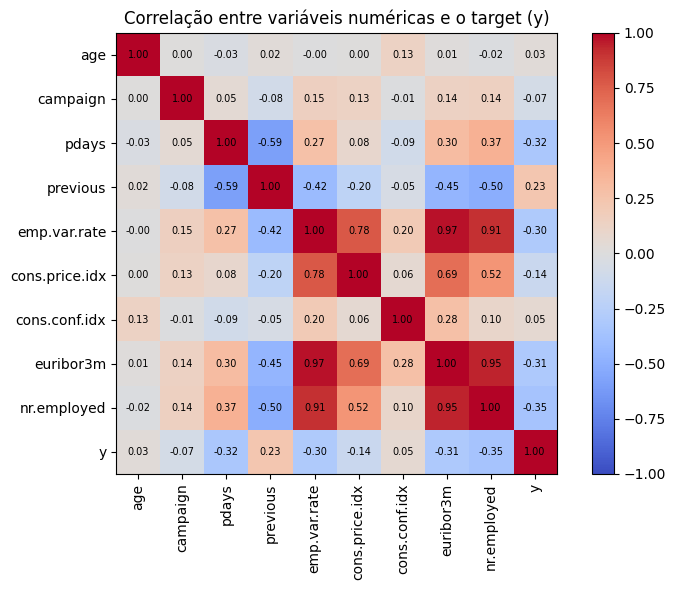

In [13]:
corr_cols = num_cols + ['y']
df_corr = df[corr_cols].copy()
df_corr['y'] = (df_corr['y'] == 'yes').astype(int)

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
fig.colorbar(im)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
plt.title('Correlação entre variáveis numéricas e o target (y)')
plt.tight_layout()
plt.show()

**Leitura:**
- As variáveis macroeconômicas são fortemente correlacionadas entre si (`emp.var.rate`, `euribor3m`, `nr.employed`), como esperado. Carregam a mesma informação de ciclo econômico. Não é necessário manter todas na modelagem final.
- `nr.employed` e `emp.var.rate` têm correlação negativa mais forte com `y` entre as numéricas, condições macroeconômicas mais fracas coincidem com mais conversão (menos emprego → produto de poupança mais atrativo).
- `previous` (contatos antes desta campanha) tem correlação positiva leve com `y`, alinhado com o achado de `poutcome = success`.

## Remoção de colunas de vazamento temporal

`duration` é a duração da última chamada, em segundos. Esse valor **só existe depois que a chamada termina** — ou seja, não está disponível no momento em que o bandit precisa decidir qual oferta apresentar. Mantê-la como feature causaria vazamento (o modelo teria acesso indireto ao resultado da própria ligação). Por isso ela é descartada aqui.

In [14]:
print("Shape antes:", df.shape)
df = df.drop(columns=['duration'])
print("Shape depois:", df.shape)
assert 'duration' not in df.columns

Shape antes: (41188, 21)
Shape depois: (41188, 20)


## Resumo da EDA

- Base com 41.188 clientes, 20 features + target, sem `NaN` explícito, mas com categoria `unknown` relevante em algumas colunas categóricas (mantida como categoria própria).
- Sem duplicatas significativas.
- Target fortemente desbalanceado (~11,3% de conversão). Métrica de comparação baseline vs. bandit deve ser taxa de conversão/regret, não acurácia.
- `pdays = 999` é uma categoria disfarçada de número ("nunca contatado antes", ~96% dos casos). Tratar como flag binária.
- Há sinal real de variação de conversão por `job`, `education`, `month` e principalmente `poutcome`, candidatos a contexto/segmentação para os braços do bandit.
- `duration` foi removida por vazamento temporal.